# Perturbation Spectrum for MNIST Image

## Read CSVs

In [2]:
## Paths
mnist_7_4_path              = "./results/mnist-sample-7-4.csv"
mnist_7_4_lb_path           = "./results/mnist-sample-7-4_lb.csv"
mnist_7_4_ub_path           = "./results/mnist-sample-7-4_ub.csv"
complete_mnist_7_4_lb_path  = "./results/complete-mnist-sample-7-4_lb.csv"
complete_mnist_7_4_ub_path  = "./results/complete-mnist-sample-7-4_ub.csv"

## Convert to Numpy
import numpy as np

mnist_7_4               = np.genfromtxt(mnist_7_4_path).reshape(784)
mnist_7_4_lb            = np.genfromtxt(mnist_7_4_lb_path).reshape(784)
mnist_7_4_ub            = np.genfromtxt(mnist_7_4_ub_path).reshape(784)
complete_mnist_7_4_lb   = np.genfromtxt(complete_mnist_7_4_lb_path).reshape(784)
complete_mnist_7_4_ub   = np.genfromtxt(complete_mnist_7_4_ub_path).reshape(784)

delta_ub                = mnist_7_4_ub - mnist_7_4
delta_lb                = mnist_7_4_lb - mnist_7_4
complete_delta_ub       = complete_mnist_7_4_ub - mnist_7_4
complete_delta_lb       = complete_mnist_7_4_lb - mnist_7_4

domain_ub               = np.ones(784)
domain_lb               = np.zeros(784)
domain_delta_ub         = domain_ub - mnist_7_4
domain_delta_lb         = domain_lb - mnist_7_4

## Figures

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 20})

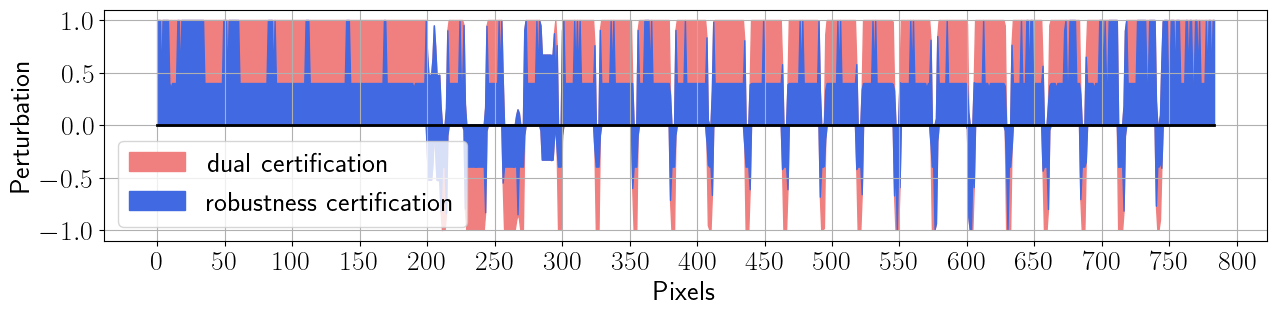

In [7]:
plt.figure(figsize=(15, 3))

# pixels
pixels = list(range(784))

# dual certification
plt.fill_between(pixels, np.zeros(784), complete_delta_ub, color="lightcoral", label="dual certification")
plt.fill_between(pixels, complete_delta_lb, np.zeros(784), color="lightcoral")

# robustness certification
plt.fill_between(pixels, np.zeros(784), delta_ub, color="royalblue", label="robustness certification")
plt.fill_between(pixels, delta_lb, np.zeros(784), color="royalblue")

## Zero Line
plt.plot(pixels, np.zeros(784), color="black", linewidth="2")

## Domain
# plt.plot(pixels, domain_delta_ub, color="green", linestyle="--")
# plt.plot(pixels, domain_delta_lb, color="green", linestyle="--")

pixels_ticks = list(range(0, 850, 50))
plt.xticks(pixels_ticks)
plt.yticks(list(np.arange(-1.0, 1.5, 0.5)))

#plt.title("Perturbation Spectrum for MNIST Image")
plt.ylabel("Perturbation")
plt.xlabel("Pixels")

## grid & legend
plt.grid(True)
plt.legend(loc="lower left")

## save as pdf
plt.savefig("spectrum.pdf", format="pdf")

## show
plt.show()